# Modele spatiale avec diffusion pour Zombie

approche des modèles épidémiques réaction-diffusion, par une méthode de diffusion de particule suivant la loi de fick :
$$
\vec{j}_n = -D\,\frac{\partial n}{\partial z}\,\vec{u}_z
$$

$$
\vec{j}_n = -D\,\nabla n
$$

On exploite ce modèle en assimant  I(t,x,y) - la densité de Zombie (les infectés) - à n la densité de particule. Ce qui donne:
$$
\vec{j}_I = -D\,\nabla I
$$

L'equation de conservation des zombies s'ecrit alors:

$$
\frac{\partial I}{\partial t} = - \operatorname{div}\,\vec{j}_I 
+ \sigma_I
$$
$$
\frac{\partial I}{\partial t} = D\,\Delta I + \sigma_I
$$

Finalement en remplacant $\sigma_I(x,y,t)$ le taux local de zombies créés par unité de surface et de temps par son expression SIRD :
$$ \beta SI - (\gamma+\mu)I $$

on a :

$$
\frac{\partial I}{\partial t} = D\,\Delta I + \beta SI - (\gamma+\mu)I
$$


On ajoute ainsi une dynamique spatiale dans l'equation differentielle de I.

### Le modele


on obtient le modèle SIRD avec diffusion qui modelise la densités :

$$
\begin{cases}
\displaystyle \frac{\partial S}{\partial t} = -\beta SI, \\[1.2ex]
\displaystyle \frac{\partial I}{\partial t} = \beta SI - (\gamma + \mu)I + D_I \Delta I, \\[1.2ex]
\displaystyle \frac{\partial R}{\partial t} = \gamma I, \\[1.2ex]
\displaystyle \frac{\partial D}{\partial t} = \mu I.
\end{cases}
$$

### Condition au limite

- Nous prenons un carré de coté L
- Nous avons les conditions au limite de flux de Zombie nul sur les bord:
$$
\vec{j}_I . \vec{u} = -D\,\nabla I . \vec{u}=0
$$

Sur le carré $[0,\ell]\times[0,\ell]$, la condition de flux nul s'écrit :
$$

\frac{\partial I}{\partial x}(0,y,t)=0,\quad
\frac{\partial I}{\partial x}(\ell,y,t)=0,\quad
\frac{\partial I}{\partial y}(x,0,t)=0,\quad
\frac{\partial I}{\partial y}(x,\ell,t)=0.

$$

### Laplacien en difference finie

Pour un pas h, le laplacien vaut :

$$
\Delta_h I_{i,j}
=
\frac{I_{i+1,j} + I_{i-1,j} + I_{i,j+1} + I_{i,j-1} - 4I_{i,j}}{h^2}.
$$


### euler avec diffrence finie

On obtien finalement, avec i,j les coordonnées sur la grille 2D, pour chaque t le système d'équation:
$$
\frac{dS_{ij}}{dt} = -\beta S_{ij} I_{ij}
$$

$$
\frac{dI_{ij}}{dt} = \beta S_{ij} I_{ij} - (\gamma+\mu) I_{ij} + D_I \Delta_h I_{ij}
$$

$$
\frac{dR_{ij}}{dt} = \gamma I_{ij}
$$

$$
\frac{dD_{ij}}{dt} = \mu I_{ij}
$$

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nosPackages.mathUtils as mathUtils

## Parametres

In [ ]:
# population initial
S_init=99.999 # personnes suscétibles (départ) en fraction -> 1=100%
I_init=0.001 # personnes infectés
R_init=0 # personnes guérit
D_init=0 # personne decede

# paramètre de contagion
beta=15 # taux de contagion journalier de base 
gamma=0.001 # 1/gamma = nb de jour contagieux
mu=1.0 # 1/ taux de decès
N=10 # pas d'espace
l=1 # taille du carré 
D=1#2e-4 # coefficient de la diffusion
h=l/N
R0=beta/(gamma+mu)*S_init # nombre de personnes contaminés par un malade = 3 pour le covid
print (R0)

4.994955044955046


In [47]:
#deriv_SIRD_euler_explicite_spatiale
#S0 = np.full((N, N), S_init)
S0 = np.ones((N, N))*100
S0[N//2,N//2]=S_init
I0 = np.zeros((N, N))
I0[N//2,N//2]=I_init
R0 = np.zeros((N, N))
Z0 = np.zeros((N, N))

y = np.array([S0, I0, R0, Z0], dtype=float)

# Calcul

In [42]:
dt = 0.1
tmax = 100.0
temps = np.arange(0, tmax + dt, dt)
n = temps.size

S = np.empty((n, N, N))
I = np.empty((n, N, N))
R = np.empty((n, N, N))
Z = np.empty((n, N, N))
Rt = np.empty((n, N, N))

params={"beta":beta,"gamma":gamma,"mu":mu,"h":h, "D":D}
model=mathUtils.SIR(params)
deriv=model.deriv_SIRD_euler_explicite_spatiale
euler=model.euler

for i in range(n):
    S[i] = y[0]
    I[i] = y[1]
    R[i] = y[2]
    Z[i] = y[3]
    t = temps[i]
    y = euler(t, dt, y, deriv)
Rt = beta/gamma*S # evolution du R0 (contagion pour une personne)

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

def anime_zombies(I, temps, l, S=None, Z=None, R=None,
                  mode="absolute",
                  gif_name="zombies.gif",
                  interval=80,
                  fps=15,
                  step=1):
    """
    Anime la carte des zombies et enregistre un GIF.

    Paramètres
    ----------
    Z : array shape (nt, N, N)
        Densité de zombies
    temps : array shape (nt,)
        Temps
    l : float
        Taille du carré physique [0,l]x[0,l]
    S, I, R : arrays shape (nt, N, N), optionnels
        Utiles si mode='ratio'
    mode : str
        'absolute' : affiche Z
        'ratio'    : affiche 100 * Z / (S+I+R+Z)
    gif_name : str
        Nom du fichier gif
    interval : int
        Temps entre 2 images à l'écran en ms
    fps : int
        Images par seconde pour le gif
    step : int
        On prend une image sur 'step'
    """

    if mode not in ("absolute", "ratio"):
        raise ValueError("mode doit valoir 'absolute' ou 'ratio'")

    if mode == "ratio":
        if S is None or Z is None or R is None:
            raise ValueError("Pour mode='ratio', il faut fournir S, I et R")
        eps = 1e-12
        data = 100.0 * I / (S + I + R + Z + eps)
        label = "% local de zombies"
        vmin, vmax = 0, 100
    else:
        data = I
        label = "Densité de zombies Z"

        # évite qu'une valeur extrême écrase la palette
        vmax = np.percentile(data, 99.5)
        if vmax <= 0:
            vmax = 1.0
        vmin = 0

    frames = np.arange(0, len(temps), step)

    fig, ax = plt.subplots(figsize=(6.5, 6))

    img = ax.imshow(
        data[frames[0]],
        origin="lower",
        extent=[0, l, 0, l],
        cmap="RdYlGn_r",      # vert -> rouge
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest",
        animated=True
    )

    cbar = plt.colorbar(img, ax=ax)
    cbar.set_label(label)

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    title = ax.set_title(f"{label} - t = {temps[frames[0]]:.2f}")

    def update(k):
        idx = frames[k]
        img.set_array(data[idx])
        title.set_text(f"{label} - t = {temps[idx]:.2f}")
        return img, title

    ani = FuncAnimation(
        fig,
        update,
        frames=len(frames),
        interval=interval,
        blit=True
    )

    ani.save(gif_name, writer=PillowWriter(fps=fps))
    print(f"GIF enregistré : {gif_name}")

    plt.show()

    return ani

GIF enregistré : zombies_absolu.gif


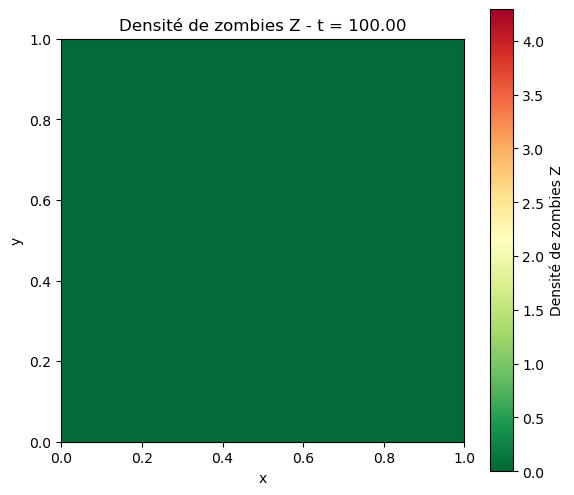

In [44]:
ani = anime_zombies(
    I=I,
    temps=temps,
    l=l,
    mode="absolute",
    gif_name="zombies_absolu.gif",
    interval=500,
    fps=2,
    step=10
)

GIF enregistré : zombies_ratio.gif


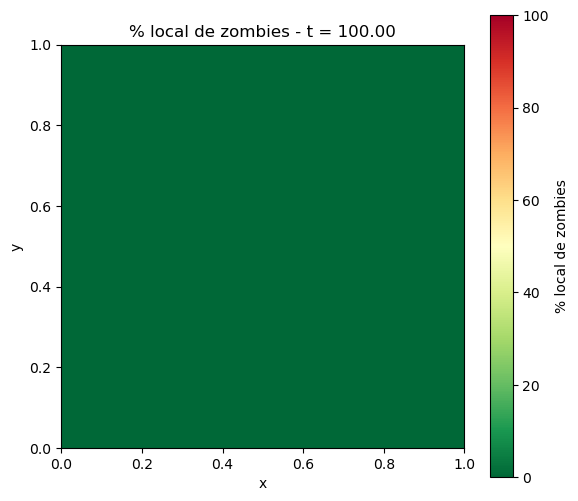

In [50]:
ani = anime_zombies(
    Z=Z,
    S=S,
    I=I,
    R=R,
    temps=temps,
    l=l,
    mode="ratio",
    gif_name="zombies_ratio.gif",
    interval=500,
    fps=2,
    step=10
)